## Import Libraries

In [105]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import MinMaxScaler , StandardScaler
from imblearn.over_sampling import SMOTE

from sklearn.feature_selection import RFECV
from sklearn.feature_selection import SelectKBest, f_classif, RFE
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.decomposition import PCA

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/datasets/survey lung cancer.csv')

In [ ]:
df.head()

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,M,69,1,2,2,1,1,2,1,2,2,2,2,2,2,YES
1,M,74,2,1,1,1,2,2,2,1,1,1,2,2,2,YES
2,F,59,1,1,1,2,1,2,1,2,1,2,2,1,2,NO
3,M,63,2,2,2,1,1,1,1,1,2,1,1,2,2,NO
4,F,63,1,2,1,1,1,1,1,2,1,2,2,1,1,NO


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   GENDER                 309 non-null    object
 1   AGE                    309 non-null    int64 
 2   SMOKING                309 non-null    int64 
 3   YELLOW_FINGERS         309 non-null    int64 
 4   ANXIETY                309 non-null    int64 
 5   PEER_PRESSURE          309 non-null    int64 
 6   CHRONIC DISEASE        309 non-null    int64 
 7   FATIGUE                309 non-null    int64 
 8   ALLERGY                309 non-null    int64 
 9   WHEEZING               309 non-null    int64 
 10  ALCOHOL CONSUMING      309 non-null    int64 
 11  COUGHING               309 non-null    int64 
 12  SHORTNESS OF BREATH    309 non-null    int64 
 13  SWALLOWING DIFFICULTY  309 non-null    int64 
 14  CHEST PAIN             309 non-null    int64 
 15  LUNG_CANCER            

In [ ]:
df.duplicated().sum()

np.int64(33)

In [ ]:
df = df.drop_duplicates()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 276 entries, 0 to 283
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   GENDER                 276 non-null    object
 1   AGE                    276 non-null    int64 
 2   SMOKING                276 non-null    int64 
 3   YELLOW_FINGERS         276 non-null    int64 
 4   ANXIETY                276 non-null    int64 
 5   PEER_PRESSURE          276 non-null    int64 
 6   CHRONIC DISEASE        276 non-null    int64 
 7   FATIGUE                276 non-null    int64 
 8   ALLERGY                276 non-null    int64 
 9   WHEEZING               276 non-null    int64 
 10  ALCOHOL CONSUMING      276 non-null    int64 
 11  COUGHING               276 non-null    int64 
 12  SHORTNESS OF BREATH    276 non-null    int64 
 13  SWALLOWING DIFFICULTY  276 non-null    int64 
 14  CHEST PAIN             276 non-null    int64 
 15  LUNG_CANCER            276 n

In [ ]:
df['LUNG_CANCER'].value_counts()

,count
LUNG_CANCER,
YES,238
NO,38


## EDA

<ipython-input-10-e07939278b32>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='LUNG_CANCER', data=df, palette=["#ff595e", "#3a86ff"])


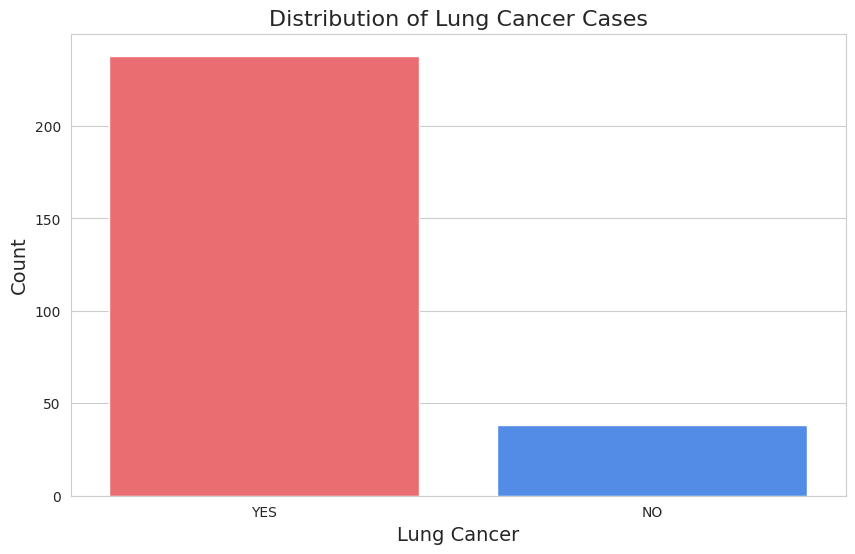

In [ ]:


# Set the aesthetic style of the plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

# Define a beautiful color palette
colors = ["#ff9e00", "#8ac926", "#1982c4", "#6a4c93", "#ff595e", "#3a86ff"]
categorical_palette = sns.color_palette(colors)
sns.set_palette(categorical_palette)

# 1. Distribution of Target Variable
plt.figure(figsize=(10, 6))
ax = sns.countplot(x='LUNG_CANCER', data=df, palette=["#ff595e", "#3a86ff"])
plt.title('Distribution of Lung Cancer Cases', fontsize=16)
plt.xlabel('Lung Cancer', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.show()



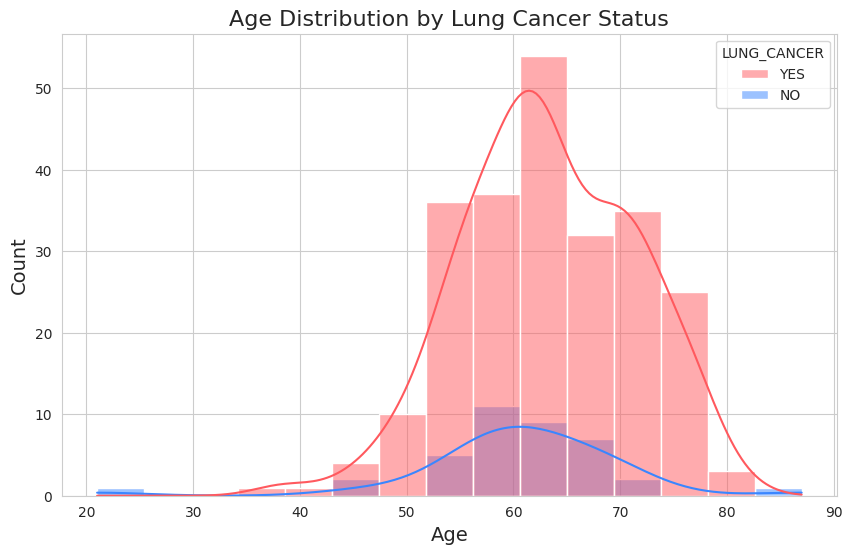

In [ ]:
# 2. Age Distribution by Lung Cancer Status
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='AGE', hue='LUNG_CANCER', bins=15, kde=True, palette=["#ff595e", "#3a86ff"])
plt.title('Age Distribution by Lung Cancer Status', fontsize=16)
plt.xlabel('Age', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.show()



<Figure size 1000x600 with 0 Axes>

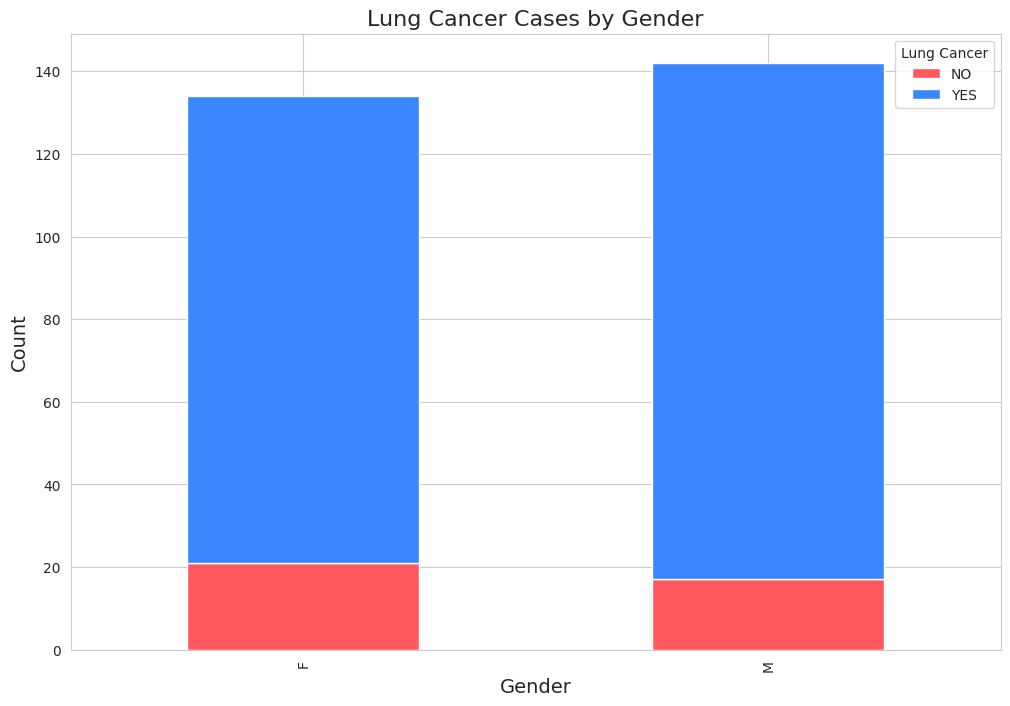

In [ ]:
# 3. Gender and Lung Cancer
plt.figure(figsize=(10, 6))
cross_tab = pd.crosstab(df['GENDER'], df['LUNG_CANCER'])
cross_tab.plot(kind='bar', stacked=True, color=["#ff595e", "#3a86ff"])
plt.title('Lung Cancer Cases by Gender', fontsize=16)
plt.xlabel('Gender', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.legend(title='Lung Cancer')
plt.show()



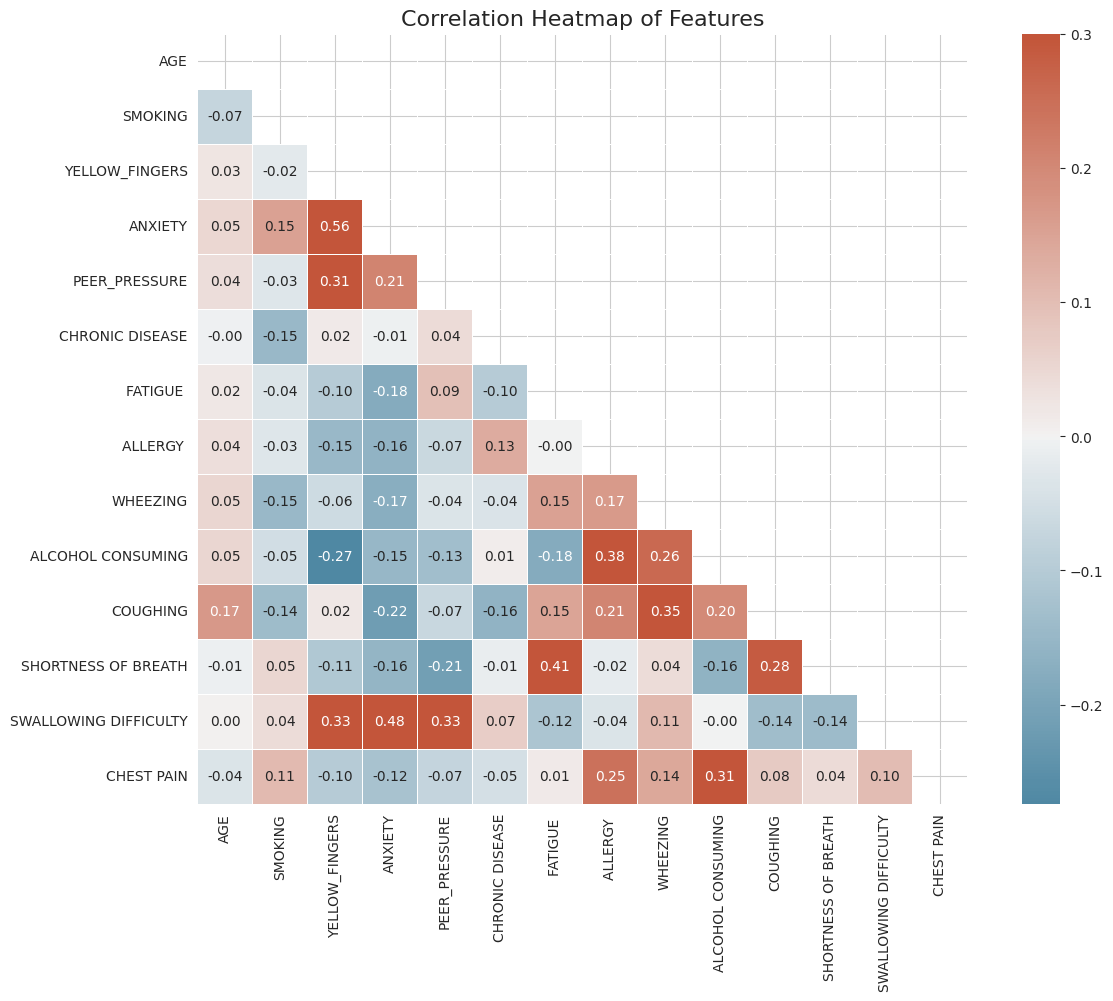

In [ ]:
# 4. Correlation Heatmap (excluding non-numeric columns)
plt.figure(figsize=(14, 10))
numeric_df = df.select_dtypes(include=['int64', 'float64'])
corr = numeric_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=.3, center=0,
            square=True, linewidths=.5, annot=True, fmt='.2f')
plt.title('Correlation Heatmap of Features', fontsize=16)
plt.show()



Exact column names in the dataframe:
'GENDER'
'AGE'
'SMOKING'
'YELLOW_FINGERS'
'ANXIETY'
'PEER_PRESSURE'
'CHRONIC DISEASE'
'FATIGUE '
'ALLERGY '
'WHEEZING'
'ALCOHOL CONSUMING'
'COUGHING'
'SHORTNESS OF BREATH'
'SWALLOWING DIFFICULTY'
'CHEST PAIN'
'LUNG_CANCER'

Possible binary features: ['SMOKING', 'YELLOW_FINGERS', 'ANXIETY', 'PEER_PRESSURE', 'CHRONIC DISEASE', 'FATIGUE ', 'ALLERGY ', 'WHEEZING', 'ALCOHOL CONSUMING', 'COUGHING', 'SHORTNESS OF BREATH', 'SWALLOWING DIFFICULTY', 'CHEST PAIN']


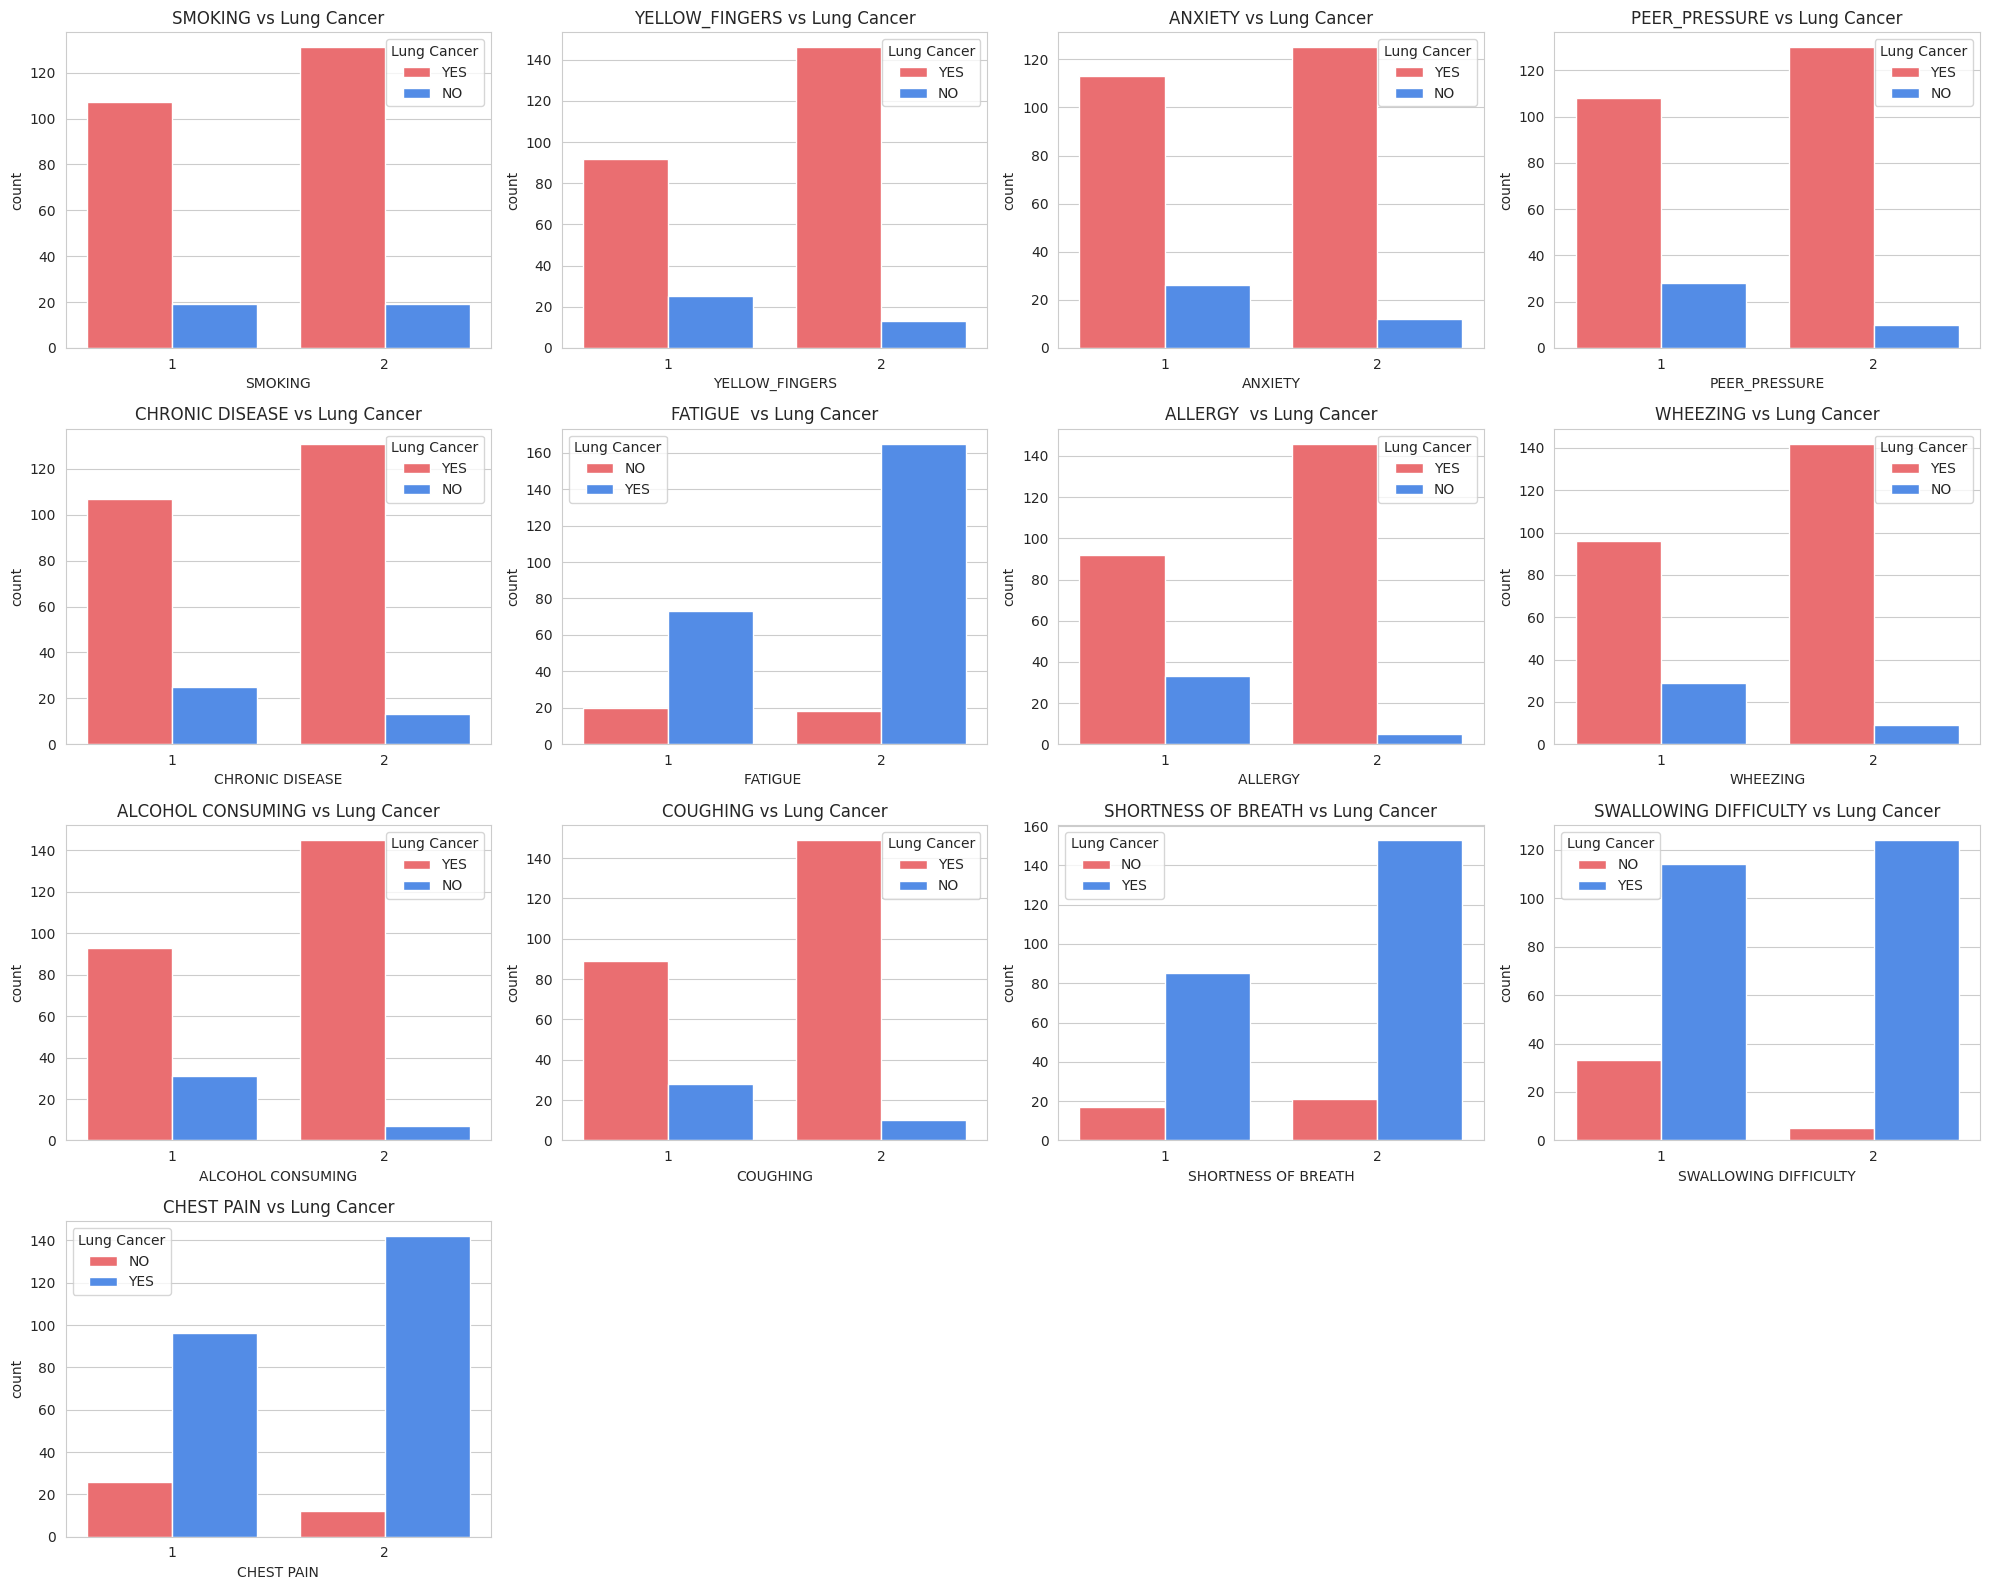

In [ ]:
# Import necessary libraries
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# First, print the exact column names to check for any spaces or formatting issues
print("Exact column names in the dataframe:")
for col in df.columns:
    print(f"'{col}'")

# Fix for Feature Distribution by Lung Cancer Status
# Define your binary features - adjusting for exact column names
# We need to make sure these match exactly what's in your dataframe

# Get all column names that could be binary features excluding GENDER, AGE and LUNG_CANCER
possible_binary_features = [col for col in df.columns if col not in ['GENDER', 'AGE', 'LUNG_CANCER']]
print("\nPossible binary features:", possible_binary_features)

# Create the visualization with the corrected column names
fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()

for i, feature in enumerate(possible_binary_features):
    if i < len(axes):
        sns.countplot(x=feature, hue='LUNG_CANCER', data=df, ax=axes[i], palette=["#ff595e", "#3a86ff"])
        axes[i].set_title(f'{feature} vs Lung Cancer')
        axes[i].legend(title='Lung Cancer')

# Remove any unused subplots
for i in range(len(possible_binary_features), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

In [ ]:
# Import necessary libraries
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# First, print the exact column names to check for any spaces or formatting issues
print("Exact column names in the dataframe:")
for col in df.columns:
    print(f"'{col}'")

# Fix for Feature Distribution by Lung Cancer Status
# Define your binary features - adjusting for exact column names
# We need to make sure these match exactly what's in your dataframe

# Get all column names that could be binary features excluding GENDER, AGE and LUNG_CANCER
possible_binary_features = [col for col in df.columns if col not in ['GENDER', 'AGE', 'LUNG_CANCER']]
print("\nPossible binary features:", possible_binary_features)

# Create the visualization with the corrected column names
fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()

for i, feature in enumerate(possible_binary_features):
    if i < len(axes):
        sns.countplot(x=feature, hue='LUNG_CANCER', data=df, ax=axes[i], palette=["#ff595e", "#3a86ff"])
        axes[i].set_title(f'{feature} vs Lung Cancer')
        axes[i].legend(title='Lung Cancer')

# Remove any unused subplots
for i in range(len(possible_binary_features), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

<ipython-input-16-cb1ed1474dff>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='LUNG_CANCER', y='AGE', data=df, palette=["#ff595e", "#3a86ff"])


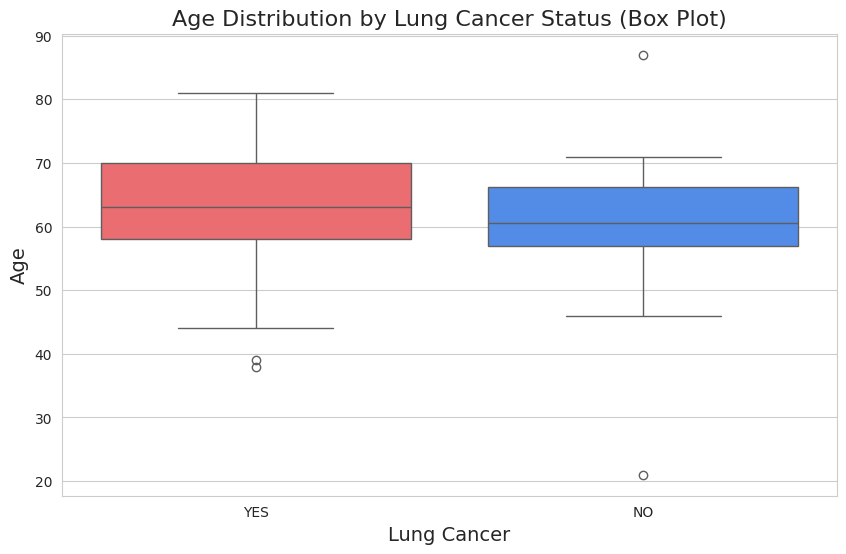

In [16]:

# 6. Box Plot for Age by Lung Cancer Status
plt.figure(figsize=(10, 6))
sns.boxplot(x='LUNG_CANCER', y='AGE', data=df, palette=["#ff595e", "#3a86ff"])
plt.title('Age Distribution by Lung Cancer Status (Box Plot)', fontsize=16)
plt.xlabel('Lung Cancer', fontsize=14)
plt.ylabel('Age', fontsize=14)
plt.show()

In [22]:

def detect_iqr_outliers(df, drop_outliers=False):
    """
    Detect outliers in a DataFrame using the IQR method and optionally drop rows with outliers.
    Only processes numeric columns and skips non-numeric ones.

    Parameters:
    -----------
    df : pandas DataFrame
        The input dataset
    drop_outliers : bool, default False
        If True, returns a DataFrame with outlier rows removed
        If False, returns a Series indicating which columns have outliers

    Returns:
    --------
    If drop_outliers=False:
        outliers : pandas Series of bool
            Boolean Series indicating which numeric columns have outliers
    If drop_outliers=True:
        df_clean : pandas DataFrame
            DataFrame with outlier rows removed
        removed_count : int
            Number of rows removed
    """
    # Select only numeric columns
    numeric_df = df.select_dtypes(include=['number'])

    if numeric_df.empty:
        print("Warning: No numeric columns found in the DataFrame")
        if drop_outliers:
            return df.copy(), 0
        else:
            return pd.Series([], dtype=bool)

    # Calculate Q1, Q3 and IQR for all numeric columns at once
    Q1 = numeric_df.quantile(0.25)
    Q3 = numeric_df.quantile(0.75)
    IQR = Q3 - Q1

    # Define bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # If just detecting outliers in columns
    if not drop_outliers:
        # Check if min is less than Q1-1.5*IQR or max is greater than Q3+1.5*IQR
        outliers = (numeric_df.min() < lower_bound) | (numeric_df.max() > upper_bound)
        return outliers

    # For dropping rows with outliers
    else:
        # Create a mask to identify outlier values in each cell
        outlier_mask = pd.DataFrame(index=df.index, columns=numeric_df.columns)

        for col in numeric_df.columns:
            # Identify outliers in this column
            outlier_mask[col] = (numeric_df[col] < lower_bound[col]) | (numeric_df[col] > upper_bound[col])

        # Rows with any outlier
        rows_with_outliers = outlier_mask.any(axis=1)

        # Count removed rows
        removed_count = rows_with_outliers.sum()
        print(f"Removed {removed_count} rows containing outliers")

        # Create clean DataFrame without outlier rows
        df_clean = df[~rows_with_outliers].copy()

        # Print which columns had outliers
        columns_with_outliers = outlier_mask.any().index[outlier_mask.any()]
        print("Columns that had outliers:", columns_with_outliers.tolist())

        return df_clean, removed_count





outliers = detect_iqr_outliers(df)
print("Columns with outliers:", outliers[outliers].index.tolist())
before = df.shape
#To detect and drop rows with outliers (returns a clean DataFrame and count of rows removed)
df, removed_count = detect_iqr_outliers(df, drop_outliers=True)
print(f"Shape before: {before}, Shape after: {df.shape}")

Columns with outliers: ['AGE']
Removed 4 rows containing outliers
Columns that had outliers: ['AGE']
Shape before: (276, 16), Shape after: (272, 16)


# Lung Cancer Exploratory Data Analysis: Insights & Recommendations

## Key Observations

### Target Variable
- **Consideration**: Apply logarithmic transformation to the target variable
- **Rationale**: This could help normalize the distribution and potentially improve model performance, especially if there's a skewed distribution of lung cancer cases

### Feature Analysis

#### Gender
- **Observation**: Gender may not be a strong predictor for lung cancer
- **Action**: Consider evaluating the feature importance of gender and potentially removing it if correlation with the target is weak

#### Age
- **Recommendation**: Categorize age into multiple groups
- **Implementation Options**:
  - Age brackets (e.g., 18-30, 31-45, 46-60, 61+)
  - Risk-based categories (young adult, middle-aged, senior)
  - Percentile-based bins
- **Benefit**: Age categorization could reveal non-linear relationships between age ranges and lung cancer risk

### Feature Engineering
- **Next Step**: Perform label encoding on categorical variables
- **Follow-up**: Generate a correlation matrix after encoding to:
  - Identify the strongest predictors of lung cancer
  - Detect potential multicollinearity between features
  - Guide feature selection for modeling

## Visualization Recommendations

1. **Correlation Heatmap**: After label encoding, create a correlation heatmap to visualize relationships between all features and the target
   
2. **Age Category Analysis**: Create barplots showing lung cancer distribution across different age categories

3. **Feature Importance Plot**: Generate a feature importance plot after fitting an initial model to confirm which features contribute most to predictions

## Next Steps

1. **Preprocessing Pipeline**:
   - Label encode categorical variables
   - Create age categories
   - Consider log transformation of relevant variables

2. **Feature Selection**:
   - Evaluate correlation matrix
   - Use feature importance from tree-based models
   - Consider removing gender if confirmed non-predictive

3. **Modeling Strategy**:
   - Start with baseline models using original and transformed features
   - Compare performance to determine optimal preprocessing approach

## SMOTE Balancing

In [25]:
le = LabelEncoder()

# Encode LUNG_CANCER (YES/NO)
df['LUNG_CANCER'] = le.fit_transform(df['LUNG_CANCER'])


# # Encode GENDER (M/F)
# df['GENDER'] = le.fit_transform(df['GENDER'])



In [30]:
df.head()

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,1,69,1,2,2,1,1,2,1,2,2,2,2,2,2,1
1,1,74,2,1,1,1,2,2,2,1,1,1,2,2,2,1
2,0,59,1,1,1,2,1,2,1,2,1,2,2,1,2,0
3,1,63,2,2,2,1,1,1,1,1,2,1,1,2,2,0
4,0,63,1,2,1,1,1,1,1,2,1,2,2,1,1,0


In [107]:
X=df.drop("LUNG_CANCER", axis=1)
y= df["LUNG_CANCER"]

In [108]:
X.columns

Index(['GENDER', 'AGE', 'SMOKING', 'YELLOW_FINGERS', 'ANXIETY',
       'PEER_PRESSURE', 'CHRONIC DISEASE', 'FATIGUE ', 'ALLERGY ', 'WHEEZING',
       'ALCOHOL CONSUMING', 'COUGHING', 'SHORTNESS OF BREATH',
       'SWALLOWING DIFFICULTY', 'CHEST PAIN'],
      dtype='object')

In [109]:
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size= 0.2 , random_state= 42 )

In [110]:
X_train.shape

(217, 15)



### Why?

* The test set should represent **real-world, unseen data** — including its **natural class imbalance**.
* Applying SMOTE to the test set would **introduce synthetic data**, making evaluation **unrealistic and misleading**.

### Correct Workflow:

1. Split your data: `train_test_split()`
2. Apply SMOTE to the **training set only**
3. Train your model on the **balanced training data**
4. Evaluate your model on the **original, imbalanced test set**


In [111]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## **Model Creation** BaseLineModel

In [112]:
kn = KNeighborsClassifier()

kn.fit(X_train , y_train)

KNeighborsClassifier()

In [113]:
kn.score(X_test , y_test)

0.8181818181818182

In [114]:
lg = LogisticRegression()

# fit means training
lg.fit(X_train , y_train)

LogisticRegression()

In [115]:
lg.score(X_test , y_test)

0.9636363636363636

In [116]:
g = GaussianNB()

g.fit(X_train , y_train)

GaussianNB()

In [117]:
g.score(X_test , y_test)

0.9090909090909091

In [118]:
svc = SVC()

svc.fit(X_train , y_train)

SVC()

In [119]:
svc.score(X_test , y_test)

0.8727272727272727

In [120]:
dt = DecisionTreeClassifier()

dt.fit(X_train , y_train)

DecisionTreeClassifier()

In [121]:
dt.score(X_test , y_test)

0.7818181818181819

## Model Selection Using RFECV

In [123]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFECV
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report

# Step 1: Split features and target
X = df.drop("LUNG_CANCER", axis=1)
y = df["LUNG_CANCER"]

# Step 2: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 3: Balance training data using SMOTE
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

# Step 4: Feature selection with RFECV using a RandomForestClassifier
estimator = RandomForestClassifier(random_state=42)
selector = RFECV(estimator, step=1, cv=5, scoring='accuracy')  # you can change scoring if needed
selector.fit(X_train_bal, y_train_bal)

# Step 5: Transform both training and test data using selected features
X_train_sel = selector.transform(X_train_bal)
X_test_sel = selector.transform(X_test)

# Step 6: Fit model on selected features
model = RandomForestClassifier(random_state=42)
model.fit(X_train_sel, y_train_bal)

# Step 7: Evaluate on test data
y_pred = model.predict(X_test_sel)
print(classification_report(y_test, y_pred))

# Optional: View selected feature names
selected_features = X.columns[selector.support_]
print("Selected features:", selected_features.tolist())


              precision    recall  f1-score   support

           0       0.67      0.50      0.57         8
           1       0.92      0.96      0.94        47

    accuracy                           0.89        55
   macro avg       0.79      0.73      0.75        55
weighted avg       0.88      0.89      0.88        55

Selected features: ['AGE', 'YELLOW_FINGERS', 'ANXIETY', 'PEER_PRESSURE', 'CHRONIC DISEASE', 'FATIGUE ', 'ALLERGY ', 'WHEEZING', 'ALCOHOL CONSUMING', 'COUGHING', 'SHORTNESS OF BREATH', 'SWALLOWING DIFFICULTY', 'CHEST PAIN']


## ✅ Full Pipeline: Model Selection + Hyperparameter Tuning

In [124]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

# 1. Split features and target
X = df.drop("LUNG_CANCER", axis=1)
y = df["LUNG_CANCER"]

# 2. Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Define models and parameter grids
models = {
    'logistic': {
        'model': LogisticRegression(max_iter=1000),
        'params': {
            'model__C': [0.1, 1, 10],
            'model__solver': ['lbfgs', 'liblinear']
        }
    },
    'random_forest': {
        'model': RandomForestClassifier(random_state=42),
        'params': {
            'model__n_estimators': [100, 200],
            'model__max_depth': [None, 10, 20]
        }
    },
    'xgboost': {
        'model': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
        'params': {
            'model__n_estimators': [100, 200],
            'model__max_depth': [3, 5],
            'model__learning_rate': [0.05, 0.1]
        }
    }
}

# 4. Run GridSearchCV for each model
best_models = {}
for name, cfg in models.items():
    print(f"\nTuning {name}...")

    pipe = Pipeline([
        ('model', cfg['model'])
    ])

    grid = GridSearchCV(pipe, cfg['params'], cv=5, scoring='accuracy', n_jobs=-1)
    grid.fit(X_train, y_train)

    best_models[name] = grid
    print(f"Best params: {grid.best_params_}")
    print(f"Best CV Accuracy: {grid.best_score_:.4f}")

# 5. Evaluate best model (based on best CV score)
best_model_name = max(best_models, key=lambda name: best_models[name].best_score_)
best_model = best_models[best_model_name]

print(f"\nBest model overall: {best_model_name}")
y_pred = best_model.predict(X_test)
print(classification_report(y_test, y_pred))



Tuning logistic...
Best params: {'model__C': 10, 'model__solver': 'lbfgs'}
Best CV Accuracy: 0.9218

Tuning random_forest...
Best params: {'model__max_depth': None, 'model__n_estimators': 200}
Best CV Accuracy: 0.9216

Tuning xgboost...
Best params: {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 100}
Best CV Accuracy: 0.9218

Best model overall: logistic
              precision    recall  f1-score   support

           0       0.80      1.00      0.89         8
           1       1.00      0.96      0.98        47

    accuracy                           0.96        55
   macro avg       0.90      0.98      0.93        55
weighted avg       0.97      0.96      0.97        55



/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [08:16:59] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
